<a href="https://colab.research.google.com/github/anggakahfi/mindrest-dicoding-bootcamp/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Gathering Data**

In [ ]:
df = pd.read_excel("Twitter_Analysis.xlsx")
df.head()

,text,hashtags,labels,label_text,text_length,hashtag_count
0,Being s mom is cleaning 24/7 the same shit ove...,"['momlife', 'kids', 'tired']",2,Bagus,131,3
1,And now we have been given the walkthru book b...,['walkthru'],0,Buruk,128,1
2,Wishing YOU Peace Joy & Love! JoyTrain MentalH...,"['Peace', 'Joy', 'Love', 'JoyTrain', 'MentalHe...",0,Buruk,166,10
3,speak-no-evil monkey Can I Be Honest With You...,"['therapy', 'help', 'NLP', 'CBT', 'hypnotherap...",1,Cukup,227,12
4,Psy Do u hv any regrets? Me No Psy Are you hap...,[],0,Buruk,196,1


# **Assesing Data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8585 entries, 0 to 8584
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           8585 non-null   object
 1   hashtags       8579 non-null   object
 2   labels         8585 non-null   int64 
 3   label_text     8585 non-null   object
 4   text_length    8585 non-null   int64 
 5   hashtag_count  8585 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 402.6+ KB


In [ ]:
df.isna().sum()

,0
text,0
hashtags,6
labels,0
label_text,0
text_length,0
hashtag_count,0


In [ ]:
print("Jumlah duplikasi:", df.duplicated().sum())

Jumlah duplikasi: 0


In [ ]:
df['labels'].value_counts().sort_index()

,count
labels,
0,4164
1,2871
2,1550


In [ ]:
df.describe(include='all')

,text,hashtags,labels,label_text,text_length,hashtag_count
count,8585,8579,8585.000000,8585,8585.000000,8585.000000
unique,8439,5570,NaN,3,NaN,NaN
top,"Mental health is hard, but memes can make it e...",[],NaN,Buruk,NaN,NaN
freq,6,1222,NaN,4164,NaN,NaN
mean,NaN,NaN,0.695515,NaN,181.194875,4.670006
std,NaN,NaN,0.756925,NaN,74.796583,5.104638
min,NaN,NaN,0.000000,NaN,11.000000,0.000000
25%,NaN,NaN,0.000000,NaN,122.000000,1.000000
50%,NaN,NaN,1.000000,NaN,193.000000,3.000000
75%,NaN,NaN,1.000000,NaN,240.000000,6.000000


#**Cleaning Data**

In [ ]:
# 1. Hapus duplikasi
df.drop_duplicates(inplace=True)
print("Jumlah duplikasi:", df.duplicated().sum())

Jumlah duplikasi: 0


In [ ]:
# 2. Isi missing values hashtags
df['hashtags'].fillna('[]', inplace=True)
df.isna().sum()

/tmp/ipykernel_2631/1268361352.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['hashtags'].fillna('[]', inplace=True)


,0
text,0
hashtags,0
labels,0
label_text,0
text_length,0
hashtag_count,0


In [ ]:
# 3. Tambah kolom label_text
label_map = {0: 'Buruk', 1: 'Cukup', 2: 'Bagus'}
df['label_text'] = df['labels'].map(label_map)

# 4. Tambah fitur text_length & hashtag_count
df['text_length'] = df['text'].apply(len)
df['hashtag_count'] = df['hashtags'].apply(
    lambda x: len([t for t in str(x).strip("[]").split(',') if t.strip() not in ['', "''"]])
)

df.describe()

,labels,text_length,hashtag_count
count,8585.000000,8585.000000,8585.000000
mean,0.695515,181.194875,4.527665
std,0.756925,74.796583,5.217694
min,0.000000,11.000000,0.000000
25%,0.000000,122.000000,1.000000
50%,1.000000,193.000000,3.000000
75%,1.000000,240.000000,6.000000
max,2.000000,1019.000000,30.000000


# **Pertanyaan Bisnis**

Pertanyaan Bisnis yang Didefinisikan:

1. Bagaimana distribusi label sentimen pada dataset?
2. Bagaimana karakteristik panjang teks tiap label?
3. Bagaimana penggunaan hashtag tiap label?
4. Hashtag apa yang paling sering muncul?

# **EDA**

In [ ]:
# Statistik panjang teks per label
df.groupby('label_text')['text_length'].agg(['mean','min','max','std']).round(2)

,mean,min,max,std
label_text,,,,
Bagus,180.53,11,605,72.38
Buruk,182.30,12,1019,76.95
Cukup,179.95,12,605,72.89


In [ ]:
# Statistik hashtag per label
df.groupby('label_text')['hashtag_count'].agg(
    rata_rata='mean', total='sum', maksimal='max'
).round(2)

,rata_rata,total,maksimal
label_text,,,
Bagus,3.79,5878,30
Buruk,5.28,21974,30
Cukup,3.84,11018,30


In [ ]:
# Tweet terpendek
df.loc[df['text_length'].idxmin(), ['text','label_text','text_length']]

,7313
text,Mood TIRED
label_text,Bagus
text_length,11


In [ ]:
# Tweet terpanjang
df.loc[df['text_length'].idxmax(), ['text','label_text','text_length']]

,5504
text,rolling on the floor laughing rolling on the ...
label_text,Buruk
text_length,1019


In [ ]:
# Ringkasan gabungan
df.groupby('label_text').agg(
    jumlah_tweet=('text','count'),
    avg_panjang_teks=('text_length','mean'),
    avg_hashtag=('hashtag_count','mean'),
    total_hashtag=('hashtag_count','sum')
).round(2)

,jumlah_tweet,avg_panjang_teks,avg_hashtag,total_hashtag
label_text,,,,
Bagus,1550,180.53,3.79,5878
Buruk,4164,182.30,5.28,21974
Cukup,2871,179.95,3.84,11018


In [ ]:
# Simpan hasil cleaning ke Excel
df.to_excel("Twitter_Analysis_cleaning.xlsx", index=False)

# **Visualisasi & Explanatorry**

**Pertanyaan 1 : Bagaimana distribusi label sentimen pada dataset?**

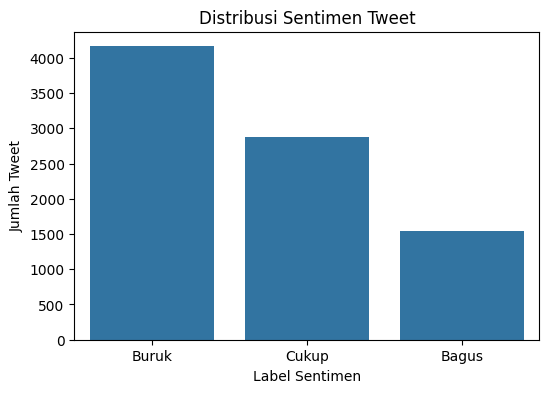

In [ ]:
#Visualisasi distribusi sentimen pada label
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label_text', order=df['label_text'].value_counts().index)
plt.title('Distribusi Sentimen Tweet')
plt.xlabel('Label Sentimen')
plt.ylabel('Jumlah Tweet')
plt.show()

**Insight**

Distribusi menunjukkan bahwa sentimen “Buruk” paling dominan, diikuti “Cukup”, dan “Bagus” paling sedikit. Hal ini mengindikasikan ketidakseimbangan kelas (class imbalance) yang berpotensi memengaruhi performa model klasifikasi di tahap berikutnya.

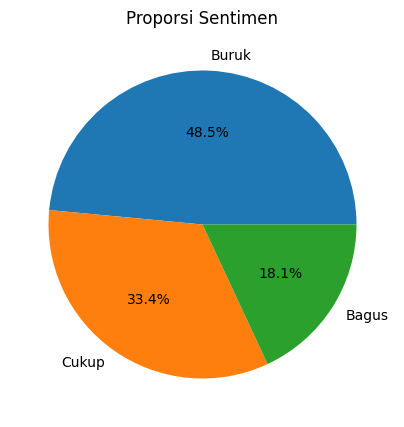

In [ ]:
#Visualisasi Proporsi Persentase Setiap Sentimen
df['label_text'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', figsize=(5,5)
)
plt.title('Proporsi Sentimen')
plt.ylabel('')
plt.show()

**Insight**

Sebagian besar tweet berada pada kategori “Buruk”, sementara “Bagus” memiliki proporsi paling kecil. Ini menegaskan adanya ketidakseimbangan distribusi data.

**Pertanyaan 2 : Bagaimana karakteristik panjang teks tiap label?**

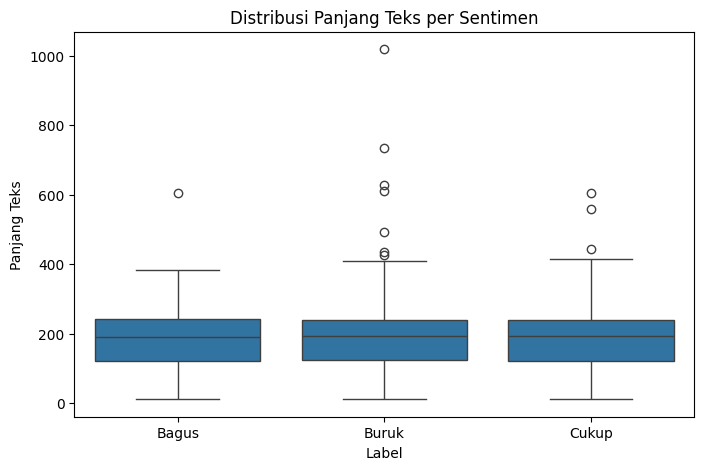

In [ ]:
#Visualisasi perbandingan panjang teks berdasarkan sentimen
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label_text', y='text_length')
plt.title('Distribusi Panjang Teks per Sentimen')
plt.xlabel('Label')
plt.ylabel('Panjang Teks')
plt.show()

**Insight**

Sebaran panjang teks pada ketiga sentimen relatif mirip, namun terdapat outlier pada setiap label. Sentimen tertentu (misalnya “Bagus”) menunjukkan variasi yang sedikit lebih lebar, menandakan adanya tweet yang sangat panjang maupun sangat pendek dalam kategori tersebut.

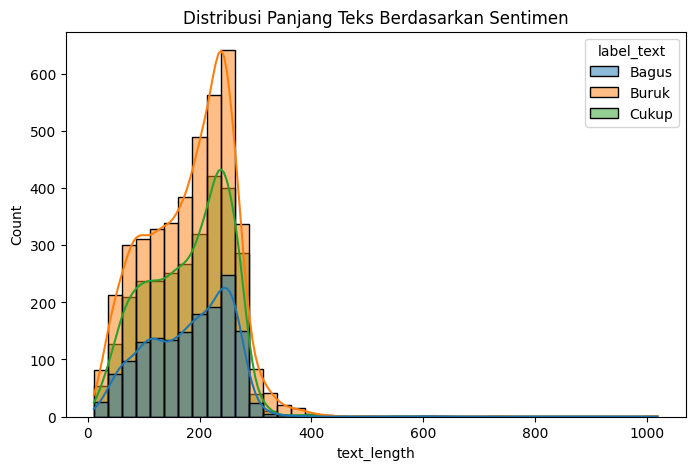

In [ ]:
#Visualisasi distribusi panjang teks per sentimen
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='text_length', hue='label_text', bins=40, kde=True)
plt.title('Distribusi Panjang Teks Berdasarkan Sentimen')
plt.show()

**Insight**

Distribusi ketiga sentimen banyak saling tumpang tindih (overlap), sehingga panjang teks saja tidak cukup untuk membedakan sentimen. Mayoritas tweet berada pada rentang panjang tertentu (menengah), dengan sedikit tweet yang sangat panjang.

**Pertanyaan 3 : Bagaimana karakteristik panjang teks tiap label?**

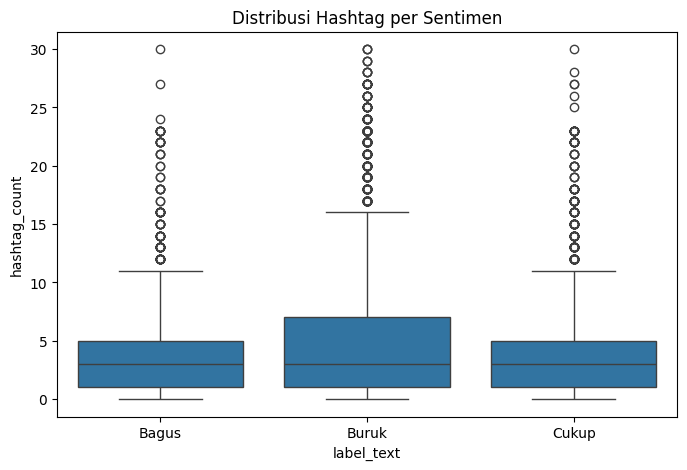

In [ ]:
#Visualisasi Perbandingan Jumlah Hashtag Berdasarkan Sentimen
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label_text', y='hashtag_count')
plt.title('Distribusi Hashtag per Sentimen')
plt.show()

**Insight**

Sebagian besar tweet pada semua sentimen memiliki jumlah hashtag yang rendah (0–2). Tidak terlihat perbedaan mencolok antar sentimen, sehingga jumlah hashtag bukan pembeda kuat untuk sentimen.

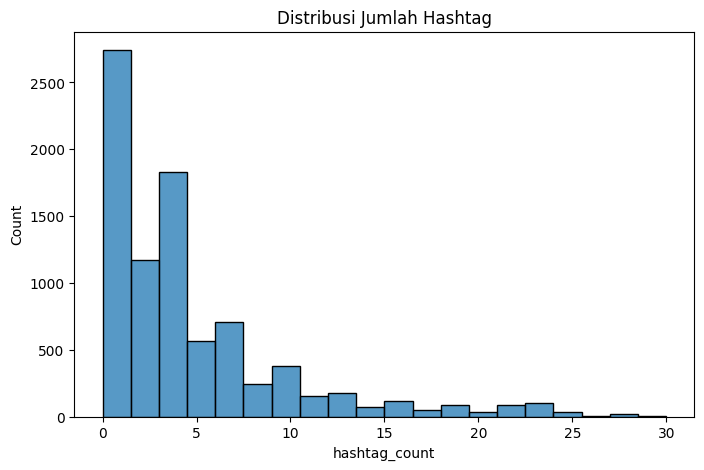

In [ ]:
#Visualisasi Distribusi Jumlah Hashtag dalam Tweet
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='hashtag_count', bins=20)
plt.title('Distribusi Jumlah Hashtag')
plt.show()

**Insight**

Distribusi sangat condong ke kiri (right-skewed), menandakan bahwa mayoritas tweet menggunakan sedikit atau tanpa hashtag. Hanya sebagian kecil tweet yang menggunakan banyak hashtag.

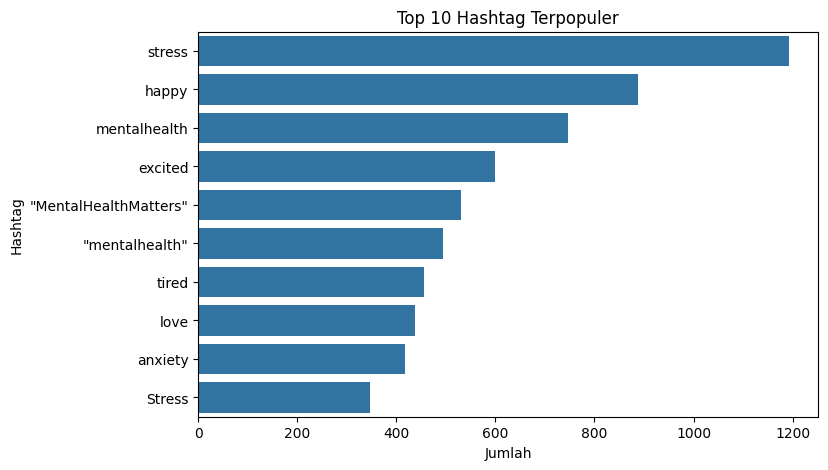

In [ ]:
#Visualisasi 10 Hashtag Paling Sering Digunakan
from collections import Counter

hashtags = []
for tag in df['hashtags']:
    tag_list = str(tag).strip("[]").replace("'", "").split(',')
    hashtags.extend([t.strip() for t in tag_list if t.strip() != ''])

top_tags = Counter(hashtags).most_common(10)
top_tags_df = pd.DataFrame(top_tags, columns=['Hashtag','Jumlah'])

plt.figure(figsize=(8,5))
sns.barplot(data=top_tags_df, x='Jumlah', y='Hashtag')
plt.title('Top 10 Hashtag Terpopuler')
plt.show()

**Insight**

Hashtag seperti “stress”, “happy”, dan “mentalhealth” muncul paling sering, menunjukkan bahwa topik utama dalam dataset berkaitan dengan kesehatan mental dan kondisi emosional.

**Visualisasi Korelasi Antar Fitur**

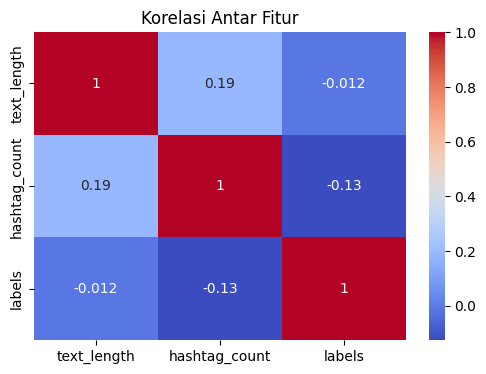

In [ ]:
#Visualisasi Korelasi Antar Fitur Numerik
plt.figure(figsize=(6,4))
sns.heatmap(df[['text_length','hashtag_count','labels']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Korelasi Antar Fitur')
plt.show()

**Insight**

Nilai korelasi antar fitur (text_length, hashtag_count, labels) cenderung rendah, sehingga tidak ada hubungan linear yang kuat. Artinya, fitur numerik ini saja kurang cukup untuk menjelaskan sentimen, dibutuhkan analisis teks (NLP).

**Visualisasi Korelasi Antara Rata-rata Panjang Teks dengan Jumlah Hashtag**

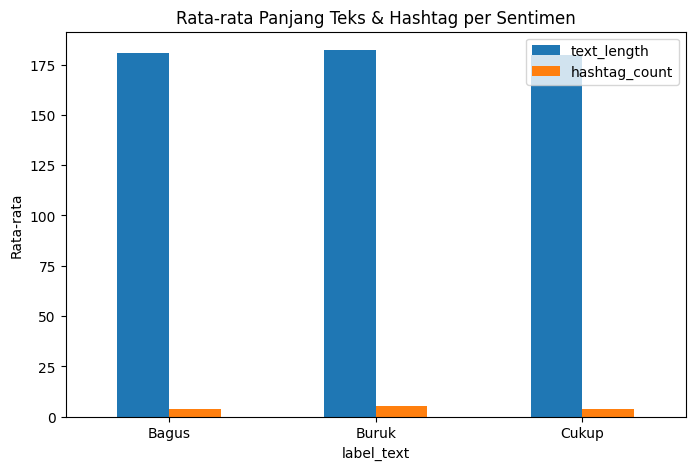

In [ ]:
#Visualisasi Rata-rata Panjang Teks dan Hashtag per Sentimen
summary_df = df.groupby('label_text').agg({
    'text_length': 'mean',
    'hashtag_count': 'mean'
}).reset_index()

summary_df.plot(x='label_text', kind='bar', figsize=(8,5))
plt.title('Rata-rata Panjang Teks & Hashtag per Sentimen')
plt.ylabel('Rata-rata')
plt.xticks(rotation=0)
plt.show()

**Insight**

Perbedaan rata-rata antar sentimen tidak terlalu signifikan. Ini menguatkan bahwa panjang teks dan jumlah hashtag bukan faktor dominan dalam menentukan sentimen.

**Visualisasi Korelasi Antara Panjang Teks dengan Jumlah Hashtag**

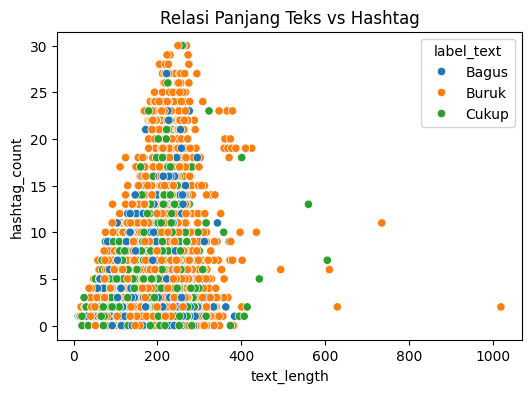

In [ ]:
#Visualisasi Hubungan Panjang Teks dan Jumlah Hashtag Berdasarkan Sentimen
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='text_length', y='hashtag_count', hue='label_text')
plt.title('Relasi Panjang Teks vs Hashtag')
plt.show()

**Insight**

Tidak terlihat pola hubungan yang jelas antara panjang teks dan jumlah hashtag. Titik data tersebar acak, menunjukkan bahwa kedua fitur ini tidak memiliki hubungan kuat dalam membedakan sentimen.

In [ ]:
#Perbandingan Hashtag Teratas pada Setiap Sentimen
from itertools import chain

df['hashtags_list'] = df['hashtags'].apply(
    lambda x: [t.strip() for t in str(x).strip("[]").replace("'", "").split(',') if t.strip()!='']
)

for label in df['label_text'].unique():
    tags = list(chain.from_iterable(df[df['label_text']==label]['hashtags_list']))
    top = Counter(tags).most_common(5)
    print(f"\nTop hashtag {label}:")
    print(top)


Top hashtag Bagus:
[('stress', 266), ('mentalhealth', 184), ('tired', 139), ('"mentalhealth"', 126), ('"MentalHealthMatters"', 119)]

Top hashtag Buruk:
[('happy', 791), ('excited', 576), ('stress', 418), ('love', 350), ('mentalhealth', 240)]

Top hashtag Cukup:
[('stress', 508), ('mentalhealth', 322), ('"MentalHealthMatters"', 265), ('tired', 246), ('"mentalhealth"', 219)]


**Insight**

* Sentimen “Bagus” banyak terkait dengan
stress dan mentalhealth
* Sentimen “Buruk” justru didominasi kata positif seperti happy dan excited
* Sentimen “Cukup” berisi campuran topik

Hashtag antar sentimen menunjukkan distribusi yang tidak selalu konsisten dengan label, yang mengindikasikan kemungkinan noise pada data atau keterbatasan fitur hashtag dalam merepresentasikan sentimen.

In [ ]:
#Crosstab Label vs Hashtag Count
pd.crosstab(df['label_text'], df['hashtag_count'])

hashtag_count,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
label_text,,,,,,,,,,,,,,,,,,,,,
Bagus,264,261,238,211,135,109,59,53,36,38,...,3,7,8,1,0,0,1,0,0,1
Buruk,516,705,520,525,324,269,220,150,131,95,...,25,36,76,24,12,7,13,4,3,3
Cukup,448,549,411,390,245,184,122,106,79,56,...,4,11,14,0,1,1,2,1,0,1


**Insight**

Mayoritas tweet di semua label memiliki 0–1 hashtag, memperkuat bahwa hashtag bukan fitur dominan. Distribusi antar label juga terlihat mirip.

In [ ]:
#Crosstab Label vs Kategori Panjang Teks
pd.crosstab(df['label_text'], pd.cut(df['text_length'], bins=5))

text_length,"(9.992, 212.6]","(212.6, 414.2]","(414.2, 615.8]","(615.8, 817.4]","(817.4, 1019.0]"
label_text,,,,,
Bagus,928,621,1,0,0
Buruk,2448,1709,4,2,1
Cukup,1702,1166,3,0,0


**Insight**

Sebagian besar tweet berada pada kategori panjang tertentu (menengah), dan distribusinya relatif merata di semua sentimen. Ini menunjukkan panjang teks tidak menjadi pembeda utama.

**Penyelesaian**

Secara keseluruhan, distribusi sentimen tidak seimbang dengan dominasi label “Buruk”. Fitur numerik seperti panjang teks dan jumlah hashtag tidak menunjukkan hubungan yang kuat terhadap sentimen. Selain itu, hashtag yang muncul tidak selalu konsisten dengan label sentimen, mengindikasikan perlunya analisis berbasis teks yang lebih mendalam untuk memahami konteks sebenarnya